# Phase 2 — Extract Entities, Normalize Terms, Analyze the Corpus

**Roadmap reference:** `ContractIQ_Project_Execution_Roadmap.md`, Phase 2

**Goal:** turn Phase 1's clause records into typed entities (dates, amounts, durations, contract-specific terms, rule-based risk indicators) — every one source-linked, semantic types kept separate, ambiguous cases left unclassified rather than guessed.

**Completion gate:** extracted entities resolve back to exact source text; ambiguous fields remain unresolved; the batch report explains all parse/extraction failures.

## 1. Load configuration and the manifest

In [1]:
import sys
sys.path.append("..")

from src.contractiq.ingestion import load_manifest
from src.contractiq.extraction import (
    run_phase2_full,
    build_eda_report,
    build_evaluation_fixture,
    process_document,
)

manifest = load_manifest()
print(f"Loaded manifest: {len(manifest)} documents")

Loaded manifest: 36 documents


## 2. Sanity check on the sample doc(s) from Phase 1

Before running the full batch, look at what gets extracted from the same sample document(s) you manually verified in Phase 1.

In [2]:
# Use the same doc_id(s) you picked in 01_Data_Manifest_and_Parsing.ipynb
SAMPLE_DOC_ID = "MLA-001"

sample_result = process_document(SAMPLE_DOC_ID)
print(f"Status: {sample_result['status']}")
print(f"Entities found: {len(sample_result['entities'])}\n")

for e in sample_result["entities"][:15]:
    print(f"[{e['entity_type']:<28}] {e['raw_text']!r:<35} "
          f"@ {e['source_location']['locator']}")

Status: extracted
Entities found: 27

[clause_term:sla_terms       ] 'service level agreement'           @ paragraph:4
[clause_term:confidentiality ] 'confidential information'          @ paragraph:4
[clause_term:confidentiality ] 'nda'                               @ paragraph:4
[clause_term:confidentiality ] 'nda'                               @ paragraph:7
[clause_term:sla_terms       ] 'uptime'                            @ paragraph:8
[clause_term:confidentiality ] 'nda'                               @ paragraph:8
[clause_term:ip_terms        ] 'intellectual property'             @ paragraph:12
[percentage                  ] '1%'                                @ paragraph:16
[clause_term:sla_terms       ] 'service level agreement'           @ paragraph:18
[clause_term:sla_terms       ] 'service level agreement'           @ paragraph:19
[clause_term:confidentiality ] 'nda'                               @ paragraph:20
[clause_term:confidentiality ] 'nda'                              

## 3. Manually review the sample above

Check a few `unclassified` dates/amounts against the actual document — are they genuinely ambiguous, or does `_DATE_CONTEXT`/`_MONEY_CONTEXT` in `extraction.py` need another keyword? Tune there before the full run, not after.

## 4. Run entity extraction across the full corpus

In [3]:
phase2_results = run_phase2_full(manifest)

Phase 2 complete: 36 documents extracted, 0 skipped (not successfully parsed in Phase 1), 457 entities total.


## 5. Corpus EDA and data-quality report

In [4]:
eda_report = build_eda_report(manifest, phase2_results)

print("\nCategory counts:")
for cat, count in eda_report["category_counts"].items():
    print(f"  {cat:<28} {count}")

print(f"\nParse success rate: {eda_report['parse_success_rate']:.1%}")
print(f"Avg word count/doc: {eda_report['avg_word_count']}")
print(f"Avg table count/doc: {eda_report['avg_table_count']}")
print(f"Avg section count/doc: {eda_report['avg_section_count']}")

if eda_report["assessed_agreements_missing_effective_date"]:
    print(f"\n⚠ Assessed agreements with no detected effective date:")
    for doc_id in eda_report["assessed_agreements_missing_effective_date"]:
        print(f"    {doc_id}")

EDA report saved to: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\PWC_CONTRACTIQ_PROJECT\artifacts\reports\phase2_eda_report.json

Category counts:
  commercial_docs              2
  compliance_docs              6
  disputes_audits_governance   4
  financial_billing            4
  historical_negotiation       6
  master_agreements            6
  operational_docs             4
  transaction_contracts        4

Parse success rate: 100.0%
Avg word count/doc: 861.4
Avg table count/doc: 0.8
Avg section count/doc: 0.0

⚠ Assessed agreements with no detected effective date:
    MLA-001
    MLA-002
    MLA-003
    MLA-004
    MLA-005
    MLA-006
    TXN-001
    TXN-002
    TXN-003
    TXN-004


## 6. Full corpus EDA dashboard

Four panels, all from real Phase 1/2 output: documents per category, word-count distribution, average document length by category, and average structure metrics (tables/sections/paragraphs) by category.

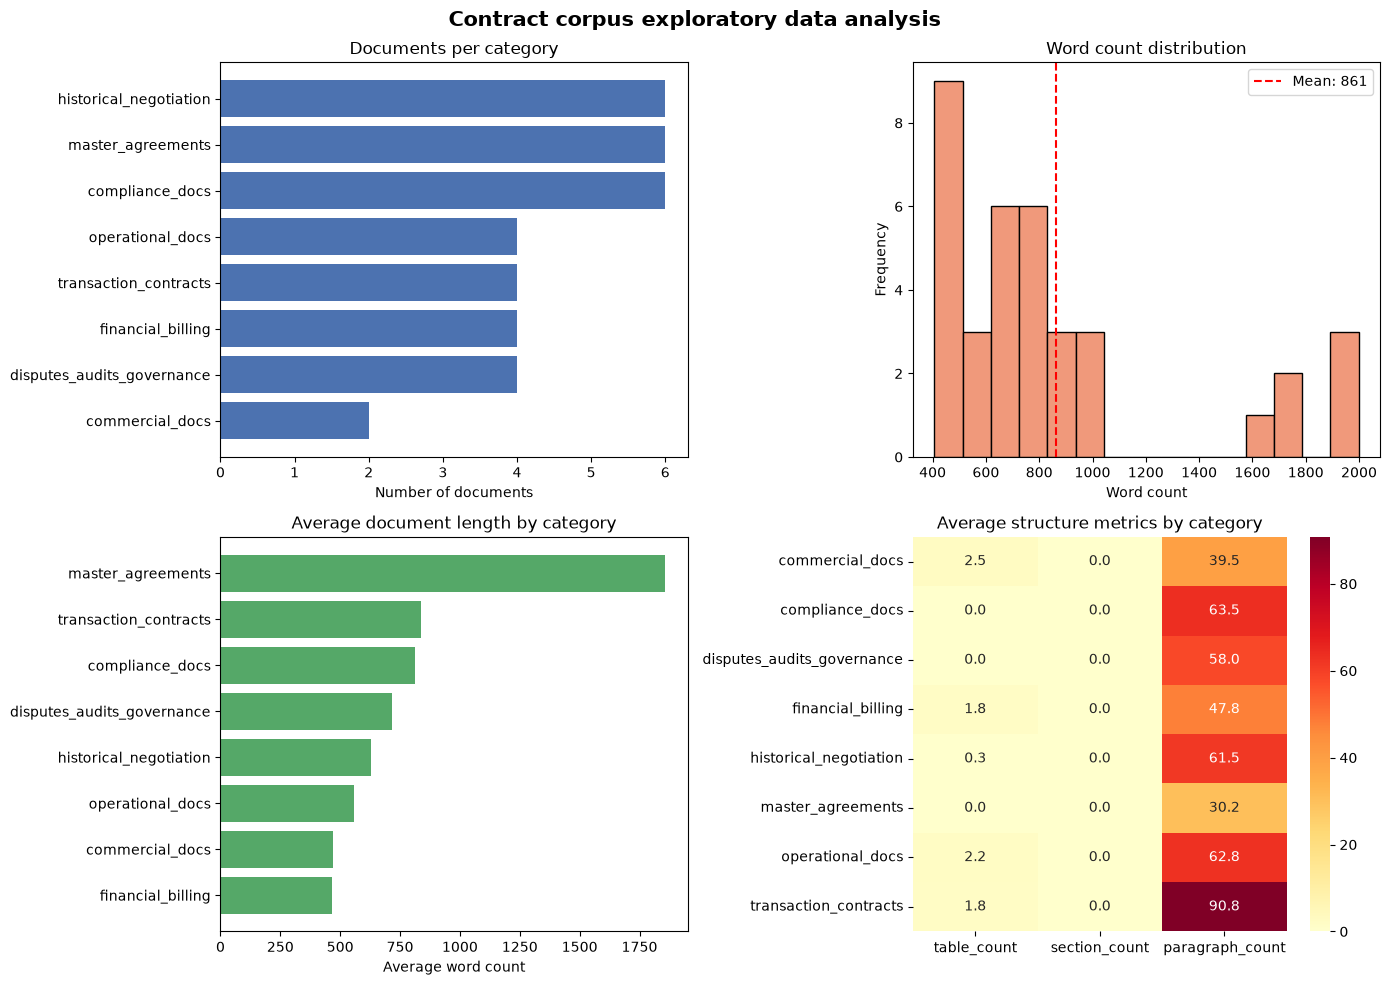

Dashboard saved to: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\PWC_CONTRACTIQ_PROJECT\artifacts\reports\phase2_eda_dashboard.png


WindowsPath('E:/Sheriff_faang/full_end_to_end_project_implementation/IK_PWC_Agentic_AI_Project/PWC_CAPSTONE_PROJECT/IK_PWC_COURSE_CAPSTONE_PROJECTS/PWC_CONTRACTIQ_PROJECT/artifacts/reports/phase2_eda_dashboard.png')

In [5]:
from src.contractiq.extraction import build_eda_dashboard

build_eda_dashboard(eda_report)

## 7. Entity type distribution (supplementary)

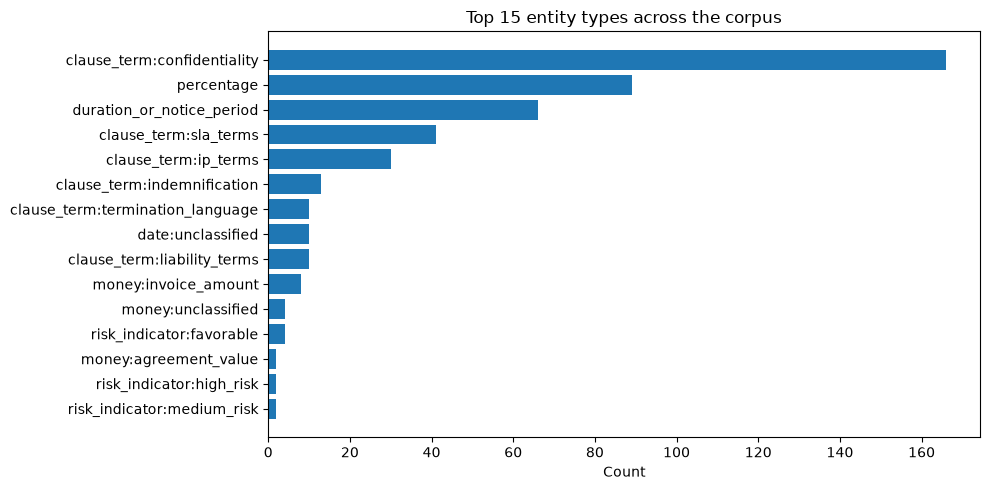

In [6]:
import matplotlib.pyplot as plt

top_entities = list(eda_report["entity_type_distribution"].items())[:15]
labels, counts = zip(*top_entities) if top_entities else ([], [])

plt.figure(figsize=(10, 5))
plt.barh(labels[::-1], counts[::-1])
plt.xlabel("Count")
plt.title("Top 15 entity types across the corpus")
plt.tight_layout()
plt.savefig("../artifacts/reports/phase2_entity_distribution.png", dpi=150)
plt.show()

## 7. Build the human-review evaluation fixture

This is the FIRST evaluation fixture the roadmap calls for (Phase 7 will build on it). It samples real extracted entities with `reviewer_verdict: null` — open the saved file and fill those in by hand before Phase 7.

In [7]:
fixture_path = build_evaluation_fixture(phase2_results, sample_size=20)

Evaluation fixture (20 rows, unreviewed) saved to: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\PWC_CONTRACTIQ_PROJECT\artifacts\evaluations\phase2_extraction_fixture.json
Open this file and fill in 'reviewer_verdict' for each row before Phase 7 uses it.


---
### Manual step before moving on

Open `artifacts/evaluations/phase2_extraction_fixture.json` and set `reviewer_verdict` to `"correct"`, `"incorrect"`, or `"ambiguous"` for each of the 20 rows, with a short note where useful. This is real signal Phase 7 depends on — don't skip it.

### Next: `03_Retrieval_and_ChromaDB.ipynb`

Chunk the parsed clauses (600-800 words, 80-120 word overlap), embed them, and build persistent, filterable semantic retrieval.